# Introduction

In this notebook, we're going to analyse the Telco Customer Churn dataset available on [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).


- First we'll use the features available to train and improve churn predictions models
- Then, we'll use these models to explain which features drive churn the most
- Finally, we'll assess the impact of some simple policies on the companies expected revenues

# Imports

ML and plotting libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc,  f1_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import ClassifierMixin
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import seaborn as sns

# Functions

A couple a re-usable helpers

In [3]:
def get_train_test_data(X: pd.DataFrame, y: pd.Series, test_size: float =0.2, random_state: int=42,):
    """Wrapper for train-test split."""
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

In [4]:
def get_preprocessor(X: pd.DataFrame, scale_numeric: bool=False):
    """Define the preprocessor piece of the pipeline.

    Indenfifies and treats differently categorical and numerical features
    """
    # Separate categorical and numeric columns
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()
    
    # Preprocessing: OneHotEncode categoricals, pass through numerics
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", StandardScaler() if scale_numeric else "passthrough", numeric_cols),
        ]
    )
    return preprocessor

In [5]:
def evaluate_model(
    model: ClassifierMixin | Pipeline,
    X_test : pd.DataFrame | np.ndarray, 
    y_test : pd.Series | np.ndarray, 
    is_soft_prediction : bool = False,
    print_report : bool = False
)->dict:
    """Evaluate a classification model on test set."""
    y_proba = model.predict_proba(X_test)[:,1] if is_soft_prediction else model.predict(X_test)
    report = classification_report(y_test, (y_proba >= 0.5).astype(int), target_names=["No Churn", "Churn"], output_dict=True)
    if print_report:
        print(classification_report(y_test, (y_proba >= 0.5).astype(int), target_names=["No Churn", "Churn"]))
    f1 = f1_score(y_test, (y_proba >= 0.5).astype(int))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba) if is_soft_prediction else np.nan

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec) if is_soft_prediction else np.nan
    return {
        "Y_Proba": y_proba,
        "FPR_list": fpr, 
        "TPR_list": tpr,
        "Precision_list":prec, 
        "Recall_list":rec, 
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Precision_Churn": report["Churn"]["precision"],
        "Recall_Churn": report["Churn"]["recall"],
        "F1_Score": f1,
    }

# Data

We load from disc the the dataset downloaded from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [6]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Feature analysis

Basic exploratory analysis. We check feature distribution and find no dangerous outliers or badly behaved features.

Shape of dataset: (7043, 21)

Data types and non-null counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non

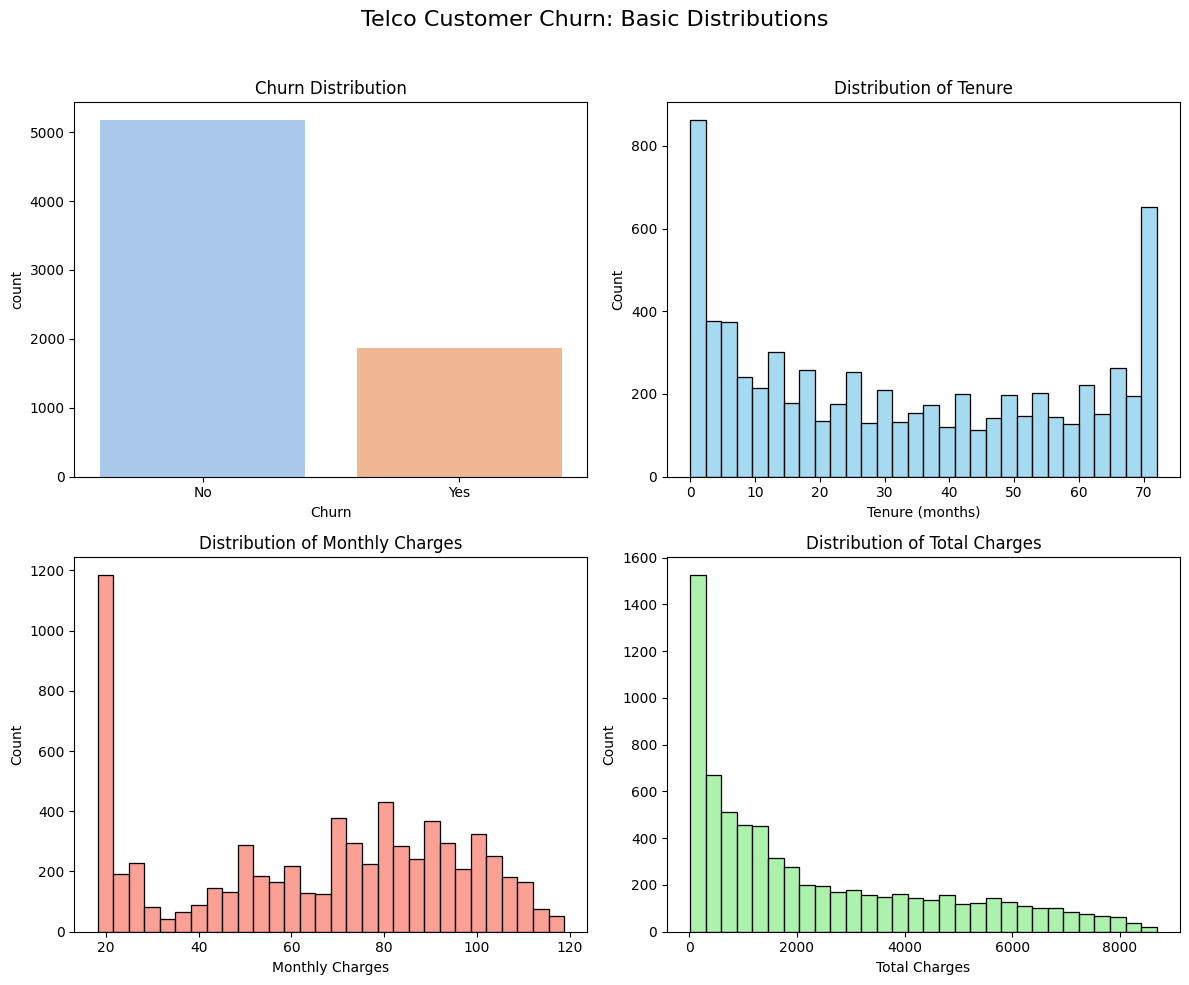


Categorical features (few unique values): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


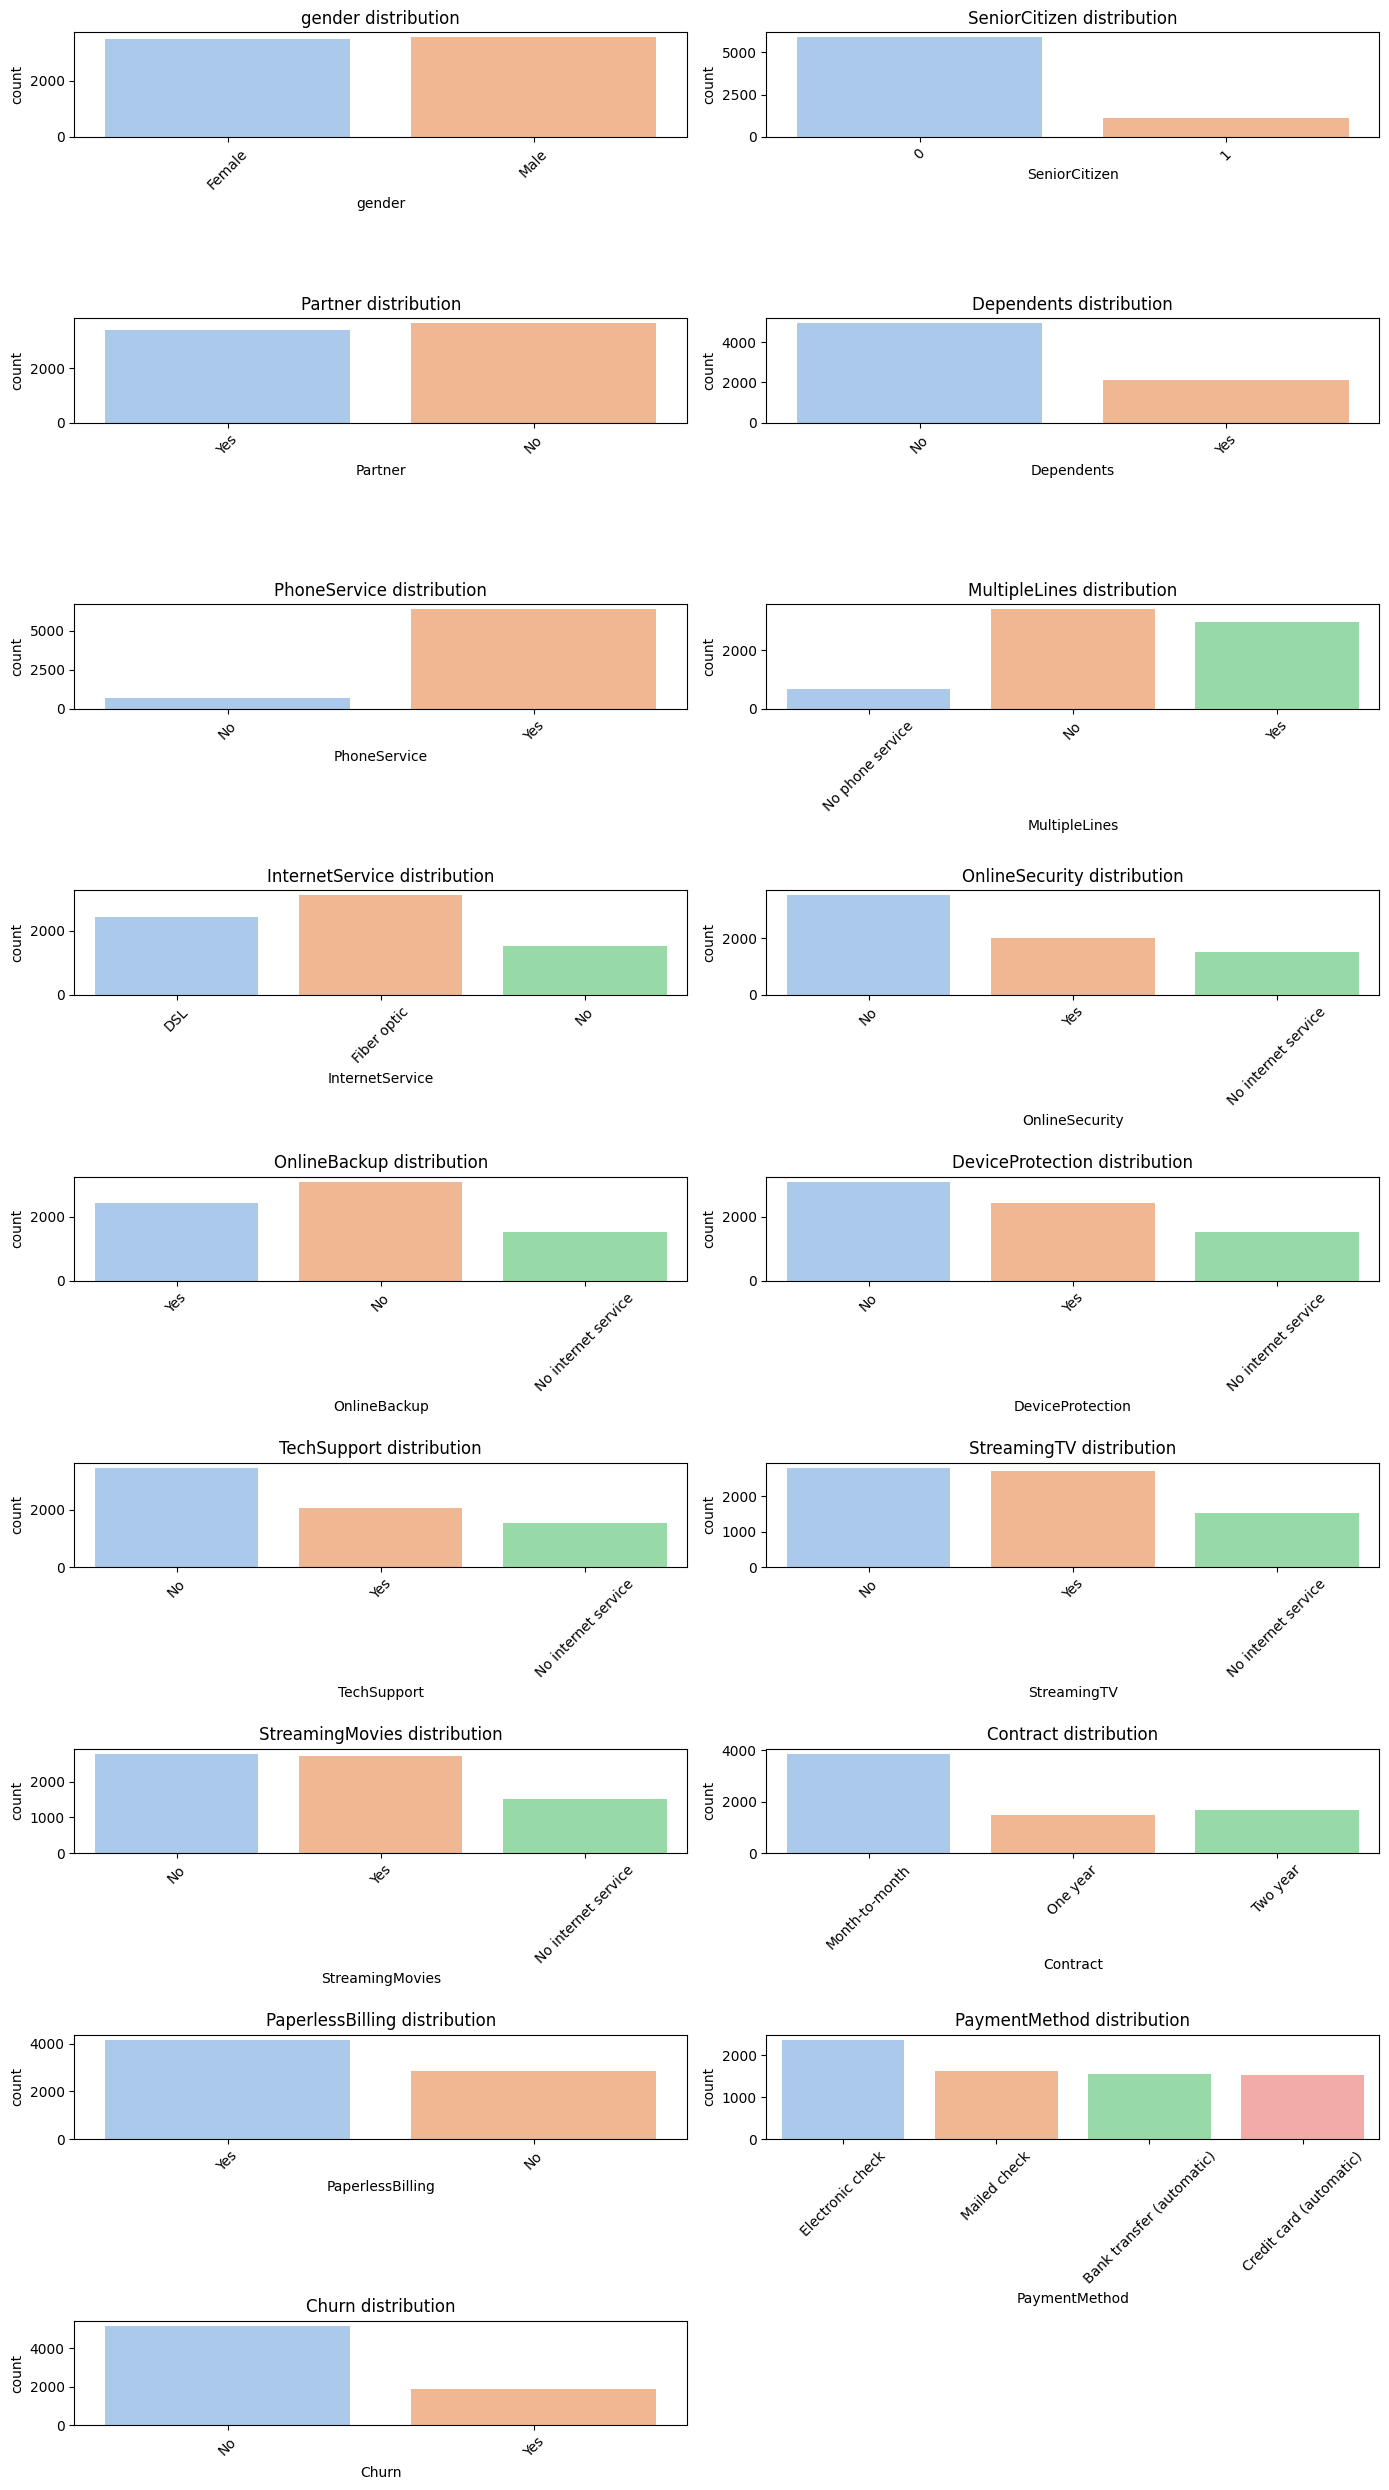

In [7]:
# Exploratory data analysis - Telco Customer Churn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Convert TotalCharges to numeric (some are blank strings)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# ---- Basic dataset overview ----
print("Shape of dataset:", df.shape)
print("\nData types and non-null counts:\n")
print(df.info())
print("\nSummary statistics (numerical):\n")
print(df.describe())
print("\nMissing values:\n")
print(df.isnull().sum())

# ---- Plots ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Telco Customer Churn: Basic Distributions", fontsize=16)

# Churn distribution
sns.countplot(x="Churn", data=df, palette="pastel", ax=axes[0,0])
axes[0,0].set_title("Churn Distribution")

# Tenure distribution
sns.histplot(df["tenure"], bins=30, kde=False, color="skyblue", ax=axes[0,1])
axes[0,1].set_title("Distribution of Tenure")
axes[0,1].set_xlabel("Tenure (months)")

# MonthlyCharges distribution
sns.histplot(df["MonthlyCharges"], bins=30, kde=False, color="salmon", ax=axes[1,0])
axes[1,0].set_title("Distribution of Monthly Charges")
axes[1,0].set_xlabel("Monthly Charges")

# TotalCharges distribution
sns.histplot(df["TotalCharges"].dropna(), bins=30, kde=False, color="lightgreen", ax=axes[1,1])
axes[1,1].set_title("Distribution of Total Charges")
axes[1,1].set_xlabel("Total Charges")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ---- Optional: categorical feature distributions ----
cat_cols = df.nunique()[df.nunique() < 10].index.tolist()
print("\nCategorical features (few unique values):", cat_cols)

fig, axes = plt.subplots(len(cat_cols)//2 + len(cat_cols)%2, 2, figsize=(14, 3*len(cat_cols)//2))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, palette="pastel", ax=axes[i])
    axes[i].set_title(f"{col} distribution")
    axes[i].tick_params(axis="x", rotation=45)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Basic cleanup

Minimal data cleanup

In [8]:
# Drop customerID (not useful)
print("df shape", df.shape)
print()
print("Processing starting")
print()
print("Drop customerID")
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges (convert to numeric, coerce errors to NaN)
print("Clean up TotalCharges")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Fill missing TotalCharges with MonthlyCharges * tenure (rough imputation)
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"], )

# Define features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})  # convert target to binary
print()
print("Processing over")
print()
print("df shape", df.shape)
print("Features shape", X.shape)

# Train/test split
X_train, X_test, y_train, y_test = get_train_test_data(X, y)

# Preprocessor
preprocessor = get_preprocessor(X)

df shape (7043, 21)

Processing starting

Drop customerID
Clean up TotalCharges

Processing over

df shape (7043, 20)
Features shape (7043, 19)


# First models

Simple exploration where we compare random forests and XGBoost (naively, without HPO), as well as analyse the impact of some extra feature engineering.

## RandomForestClassifier

In [9]:
def get_random_forest_pipeline(preprocessor: ColumnTransformer)->Pipeline:
    """Simple wrapper to redfine the RF pipeline as we change the features, hence the preprocessor"""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",   # handle imbalance
        ))
    ])


Classification Report:

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC AUC: 0.8207393629388516


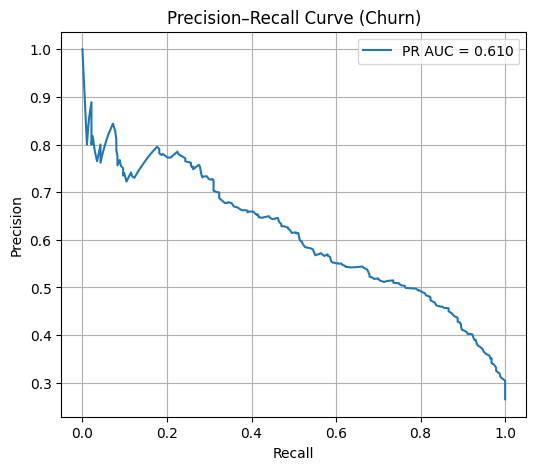

In [10]:
# Build pipeline with RandomForest
rf_pipeline = get_random_forest_pipeline(preprocessor)

# Fit model
rf_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))

# Precision–Recall Curve
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_proba)
rf_pr_auc = auc(rf_rec, rf_prec)

plt.figure(figsize=(6,5))
plt.plot(rf_rec, rf_prec, label=f"PR AUC = {rf_pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Churn)")
plt.legend()
plt.grid(True)
plt.show()

## Compare RandomForestClassifier and XGBoost

In [11]:
def get_xgb_pipeline(preprocessor: ColumnTransformer, scale_pos_weight: float)->Pipeline:
    """Simple wrapper to redfine the XGB pipeline as we change the features, hence the preprocessor"""
    return Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),
        random_state=42,
        eval_metric="logloss"
    ))
])


📊 XGBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1035
       Churn       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.76      0.77      1409

ROC AUC: 0.8262251672737607


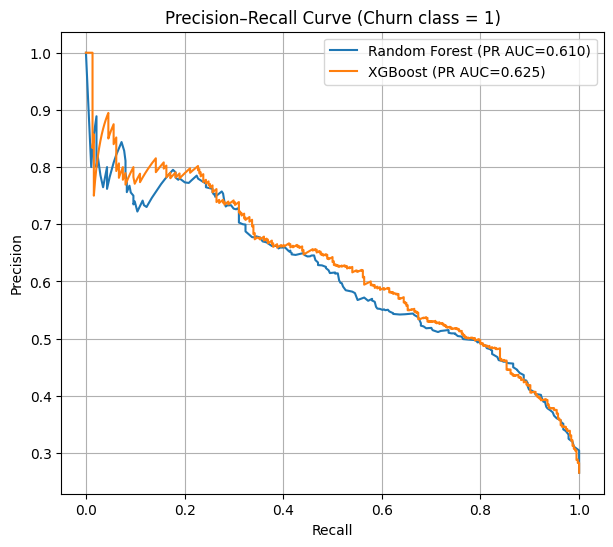

In [12]:
# XGBoost Pipeline
xgb_pipeline = get_xgb_pipeline(
    preprocessor, 
    scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1])
)

# Fit model
xgb_pipeline.fit(X_train, y_train)

#  Predictions 
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("\n📊 XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=["No Churn", "Churn"]))
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))

# Precision–Recall Curves
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_proba)
xgb_pr_auc = auc(xgb_rec, xgb_prec)

plt.figure(figsize=(7,6))
plt.plot(rf_rec, rf_prec, label=f"Random Forest (PR AUC={rf_pr_auc:.3f})")
plt.plot(xgb_rec, xgb_prec, label=f"XGBoost (PR AUC={xgb_pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Churn class = 1)")
plt.legend()
plt.grid(True)
plt.show()


## More feature engineering

Let's add some sensible feature transformations

- **Average Charges per Month**  
  AvgCharges = TotalCharges / (tenure + 1)  
  (adding +1 avoids division by zero)

- **Charges Increase Ratio**  
  ChargesIncrease = MonthlyCharges / (AvgCharges + 1)  
  Compares the most recent monthly charge with the historical average.

- **New Customer Flag**  
  IsNewCustomer = 1 if tenure < 6 months, else 0

- **Tenure Buckets**  
  Customers are grouped into ranges:  
  - 0–12 months  
  - 13–24 months  
  - 25–48 months  
  - 49–72 months  

- **Simplified Categorical Variables**  
  - "No internet service" → "No"  
  - "No phone service" → "No"  

- **Interaction Feature**  
  Contract_PaymentMethod = Contract + "_" + PaymentMethod  

- **Dropped Columns**  
  - TotalCharges (replaced by AvgCharges)  

In [13]:
# New features
# Adding the avg paid charges accross the tenure
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)
df["ChargesIncrease"] = df["MonthlyCharges"] / (df["AvgCharges"]+1)
df["IsNewCustomer"] = (df["tenure"] < 6).astype(int)

# Bucket tenure
bins = [0, 12, 24, 48, 72]
labels = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

# Simplify categorical levels
cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in cols:
    df[col] = df[col].replace({"No internet service": "No"})
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

# Contract + PaymentMethod interaction
df["Contract_PaymentMethod"] = df["Contract"] + "_" + df["PaymentMethod"]

# Dropping total charges, as it's now a proxy for tenure 
X = df.drop(["TotalCharges", "Churn"], axis=1)
print("Features shape", X.shape)

Features shape (7043, 23)


In [14]:
# Train/test split
X_train, X_test, y_train, y_test = get_train_test_data(X, y)
# Preprocessor
preprocessor = get_preprocessor(X)

Retrain both models

In [15]:
# ReFit RF
rf_pipeline = get_random_forest_pipeline(preprocessor)
rf_pipeline.fit(X_train, y_train)

# Predictions
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# Precision–Recall Curve
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_proba)
rf_pr_auc = auc(rf_rec, rf_prec)

In [16]:
# ReFit XGB
xgb_pipeline = get_xgb_pipeline(
    preprocessor, 
    scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1])
)
xgb_pipeline.fit(X_train, y_train)

#  Predictions 
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# Precision–Recall Curves
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_proba)
xgb_pr_auc = auc(xgb_rec, xgb_prec)


📊 Random Forest Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC AUC: 0.8277932780490326

📊 XGBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.76      0.77      1409

ROC AUC: 0.8276628174326384


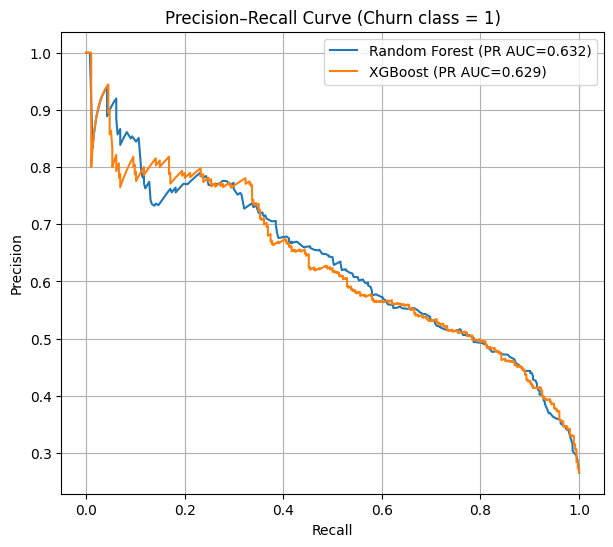

In [17]:
# Evaluation
print("\n📊 Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))

print("\n📊 XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=["No Churn", "Churn"]))
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))

plt.figure(figsize=(7,6))
plt.plot(rf_rec, rf_prec, label=f"Random Forest (PR AUC={rf_pr_auc:.3f})")
plt.plot(xgb_rec, xgb_prec, label=f"XGBoost (PR AUC={xgb_pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Churn class = 1)")
plt.legend()
plt.grid(True)
plt.show()

RF got a massive performance boost and overtook XGBoost with that feature engineering

# Comparing nine different models 

Let's define several models from different families and compare all of them.
This isn't the most exhaustive analysis as we don't optimise hyper-parameters, but rather a showcase of what these models can do with no tuning. 

In [18]:
%%time
# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]),eval_metric="logloss", random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, class_weight="balanced", verbose=0,),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42, class_weights=[1, y_train.value_counts()[0]/y_train.value_counts()[1]]),
    "Logistic Regression": LogisticRegression(max_iter=10_000, class_weight="balanced", random_state=42,),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=10, )
}

# Evaluate all models
results = []
y_proba_dict = {}
roc_info = {}
pr_info = {}
pipes = {}
for name, model in models.items():
    pipes[name] = pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    is_soft_prediction = hasattr(pipe.named_steps['model'], "predict_proba") 

    metrics = evaluate_model(pipe, X_test, y_test, is_soft_prediction)

    roc_info[name] = (metrics["FPR_list"], metrics["TPR_list"],  metrics["ROC_AUC"])
    pr_info[name] = (metrics["Precision_list"], metrics["Recall_list"],  metrics["PR_AUC"])

    results.append({
        "Model": name,
        "PR_AUC": metrics["PR_AUC"],
        "ROC_AUC": metrics["ROC_AUC"],
        "Precision_Churn": metrics["Precision_Churn"],
        "Recall_Churn": metrics["Recall_Churn"],
        "F1 score": metrics["F1_Score"],
    })
    y_proba_dict[name] = metrics["Y_Proba"] 



# Compare in a DataFrame
results_df = pd.DataFrame(results).sort_values(by="PR_AUC", ascending=False)
display(results_df)

,Model,PR_AUC,ROC_AUC,Precision_Churn,Recall_Churn,F1 score
4,Logistic Regression,0.659113,0.846679,0.508532,0.796791,0.620833
3,CatBoost,0.651403,0.835023,0.530097,0.729947,0.614173
7,Decision Tree,0.639165,0.831117,0.513089,0.786096,0.620908
0,Random Forest,0.631920,0.827793,0.632450,0.510695,0.565089
1,XGBoost,0.628891,0.827665,0.544858,0.665775,0.599278
2,LightGBM,0.624927,0.827703,0.541578,0.679144,0.602610
5,Gradient Boosting,0.612531,0.823157,0.590625,0.505348,0.544669
6,Extra Trees,0.581160,0.791302,0.568627,0.465241,0.511765
8,KNN,0.571142,0.803490,0.576408,0.574866,0.575636


CPU times: total: 47.6 s
Wall time: 16.4 s


We take an ensemble (average probability) of the best three models, and observe a performance boost.

Of course, this is "cheating" since knowledge of which models are the three best requires looking at the test set.

Nevertheless, a good showcase of the power of ensembling

In [19]:
# what would an ensemble of the three best models look like?
ensemble_list = ["Logistic Regression", "CatBoost", "Decision Tree"]
y_proba = 0
for name in ensemble_list:
    y_proba += y_proba_dict[name] / len(ensemble_list)
# ensemble
name = "Ensemble"
report = classification_report(y_test, (y_proba >= 0.5).astype(int), target_names=["No Churn", "Churn"], output_dict=True)
f1 = f1_score(y_test, (y_proba >= 0.5).astype(int))

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
roc_info[name] = (fpr, tpr, roc_auc)

prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec) 
pr_info[name] = (prec, rec, pr_auc)

results.append({
    "Model": name,
    "PR_AUC": pr_auc,
    "ROC_AUC": roc_auc,
    "Precision_Churn": report["Churn"]["precision"],
    "Recall_Churn": report["Churn"]["recall"],
    "F1 score": f1,
})
# Compare in a DataFrame
results_df = pd.DataFrame(results).sort_values(by="PR_AUC", ascending=False)
display(results_df)

,Model,PR_AUC,ROC_AUC,Precision_Churn,Recall_Churn,F1 score
9,Ensemble,0.662984,0.846850,0.530797,0.783422,0.632829
4,Logistic Regression,0.659113,0.846679,0.508532,0.796791,0.620833
3,CatBoost,0.651403,0.835023,0.530097,0.729947,0.614173
7,Decision Tree,0.639165,0.831117,0.513089,0.786096,0.620908
0,Random Forest,0.631920,0.827793,0.632450,0.510695,0.565089
1,XGBoost,0.628891,0.827665,0.544858,0.665775,0.599278
2,LightGBM,0.624927,0.827703,0.541578,0.679144,0.602610
5,Gradient Boosting,0.612531,0.823157,0.590625,0.505348,0.544669
6,Extra Trees,0.581160,0.791302,0.568627,0.465241,0.511765
8,KNN,0.571142,0.803490,0.576408,0.574866,0.575636


ROC and PR curves

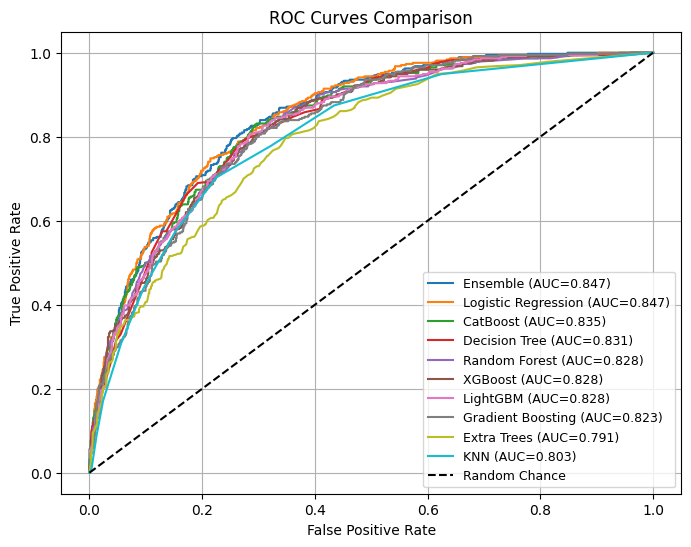

In [20]:
# Plot all ROC curves
plt.figure(figsize=(8,6))
for name in results_df.Model:
    fpr, tpr, auc_score = roc_info[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
    
plt.plot([0,1], [0,1], "k--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.show()

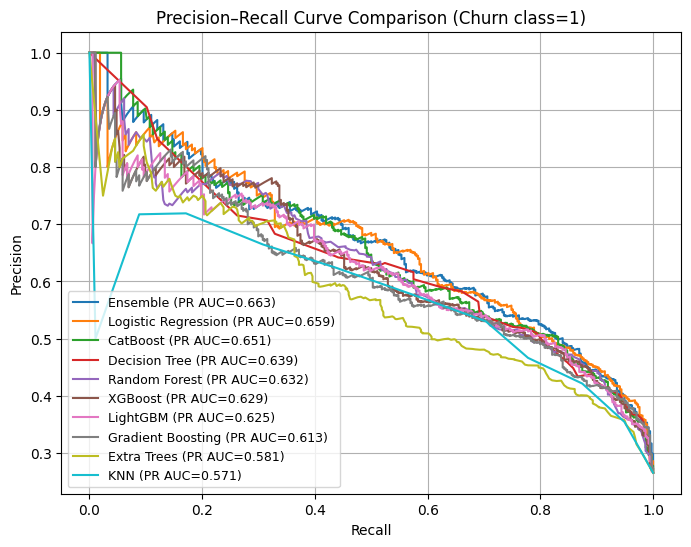

In [21]:
# Plot all PR curves
plt.figure(figsize=(8,6))
for name in results_df.Model:
    precision, recall, pr_auc = pr_info[name]
    plt.plot(recall, precision, label=f"{name} (PR AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (Churn class=1)")
plt.legend(loc="lower left", fontsize=9)
plt.grid(True)
plt.show()

# Explainability Logistic regression

We can take the best model, Logistic Regression, and use naive notions of feature importance to describe how it makes its predictions

In [22]:
# Get raw coefficients
coefficients = pipes["Logistic Regression"].named_steps['model'].coef_[0]  # for binary classification
odds_ratios = np.exp(coefficients)
# Get feature names after preprocessing
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratios": odds_ratios,
    "abs_importance": np.abs(coefficients)
}).sort_values("odds_ratios", ascending=False)

display(importance.iloc[:10])

,feature,coefficient,odds_ratios,abs_importance
11,cat__InternetService_Fiber optic,1.214058,3.367122,1.214058
25,cat__Contract_Month-to-month,0.692793,1.999292,0.692793
55,num__IsNewCustomer,0.448001,1.565180,0.448001
41,cat__Contract_PaymentMethod_Month-to-month_Mai...,0.375850,1.456228,0.375850
32,cat__PaymentMethod_Electronic check,0.318084,1.374492,0.318084
24,cat__StreamingMovies_Yes,0.264061,1.302208,0.264061
22,cat__StreamingTV_Yes,0.251613,1.286098,0.251613
9,cat__MultipleLines_Yes,0.232688,1.261988,0.232688
29,cat__PaperlessBilling_Yes,0.198337,1.219374,0.198337
48,cat__Contract_PaymentMethod_Two year_Electroni...,0.172401,1.188154,0.172401


# Explainability CatBoost

Catboost, the second best model, supports many more explainability features. We will focus on it from now on. 

## Feature importance

Natively supported feature importance.

Charges, Ratio between current and historical avg charges and tenure are the most important features

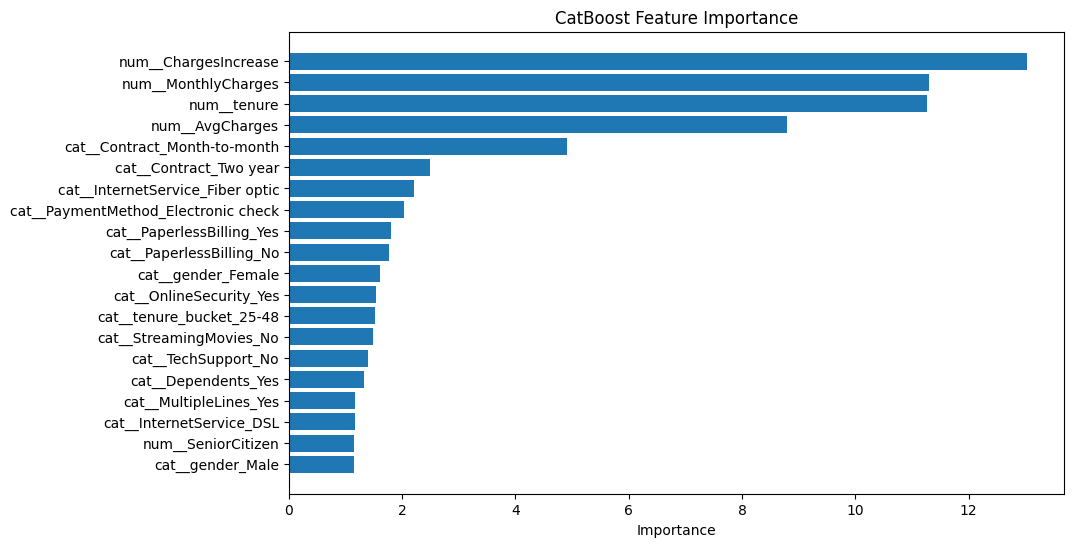

In [23]:
# Extract CatBoost model from pipeline
model = pipes["CatBoost"].named_steps['model']

# Feature names after preprocessing
feature_names = pipes["CatBoost"].named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.get_feature_importance()
indices = np.argsort(importances)[::-1]

# Plot top 20 features
plt.figure(figsize=(10,6))
plt.barh(range(20), importances[indices][:20][::-1])
plt.yticks(range(20), [feature_names[i] for i in indices][:20][::-1])
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()

## Partial dependence

Partial dependence analysis allows us to assess the impact of individual features on the model

https://scikit-learn.org/stable/modules/partial_dependence.html

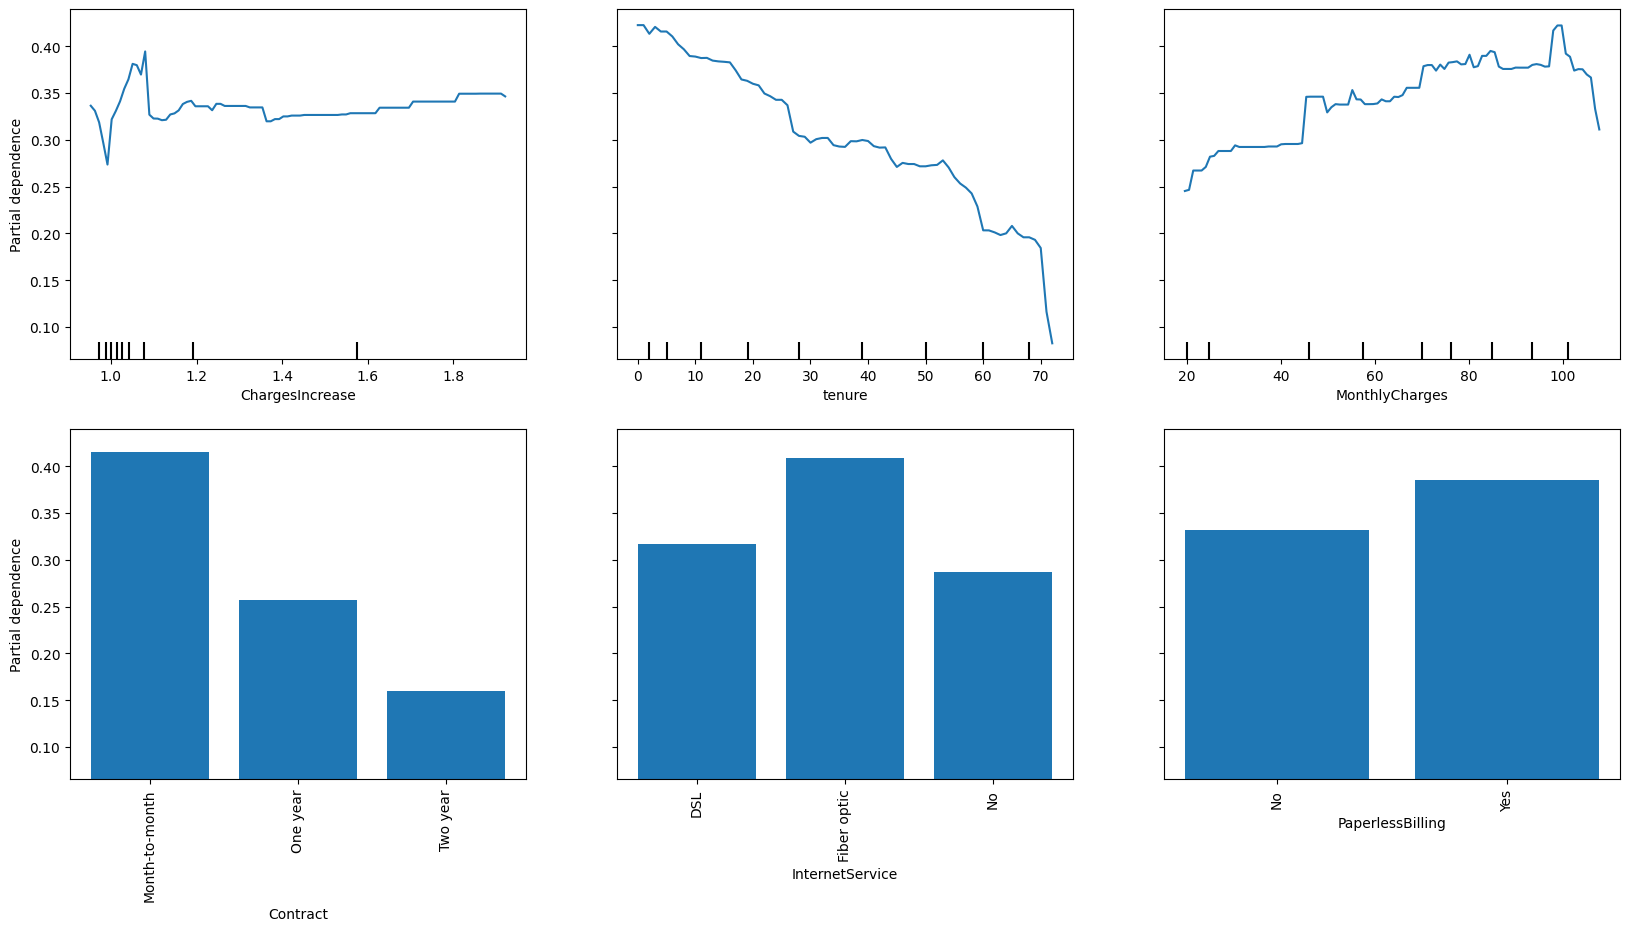

In [24]:
# Example: PDP for tenure
fig, ax = plt.subplots(figsize=(20,10))
PartialDependenceDisplay.from_estimator(
    pipes["CatBoost"],
    X_test,
    features=["ChargesIncrease", "tenure", "MonthlyCharges", "Contract", "InternetService", "PaperlessBilling",],
    categorical_features=["Contract", "InternetService", "PaperlessBilling",], 
    kind="average",
    ax=ax
)


We can see how easily a price increase of a few percent affects the probaility of churning. Larger price increase seem to have lower effect, but correspond to a small portion of the data only
- Longer tenure linearly decrease the probabilty of churning
- Higher monthly charges increase it
- Longer term contracts are better for rentention
- Fiber optic is an impopular service
- Paperless billing is worst for retention

## SHAP analysis

SHAP (SHapley Additive exPlanations) is a model-agnostic explanation method that assigns each input feature a “contribution” (positive or negative) toward a model’s prediction, doing so in a fair way (based on Shapley values) and such that the sum of contributions equals the difference between the prediction and a baseline.

https://www.geeksforgeeks.org/machine-learning/shap-a-comprehensive-guide-to-shapley-additive-explanations/

In [25]:
y_proba = pipes["CatBoost"].predict_proba(X_test)[:,1] 
idx_max_churn_proba = np.argmax(y_proba)
idx_min_churn_proba = np.argmin(y_proba)

The summary plot offers a more quantified view of how feature values (high in red, low in blue) affects the model prediction (high number = churn, low number = no churn) 
It allows us to visualise every point in the dataset in a single plot.

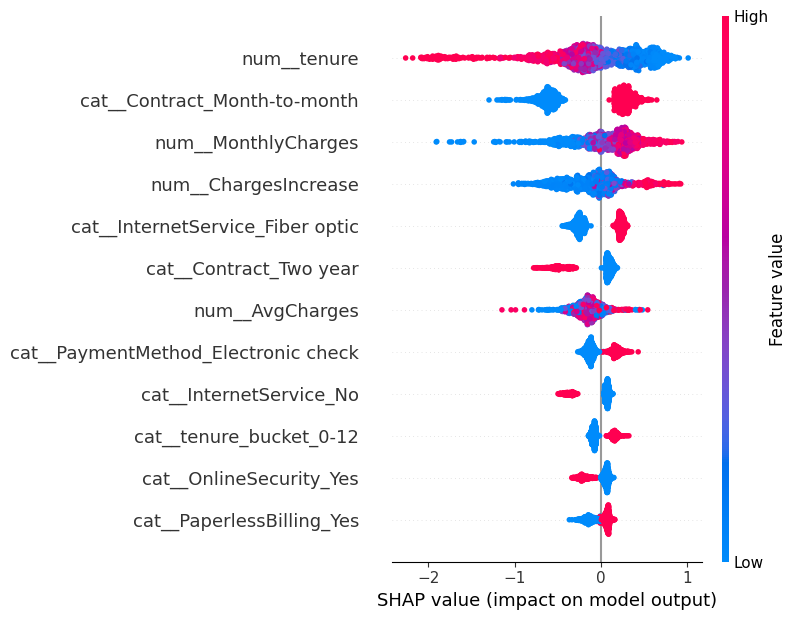

In [26]:
# Create explainer
name="CatBoost"
explainer = shap.TreeExplainer(pipes[name].named_steps['model'])
X_test_transformed = pipes[name].named_steps["preprocessor"].transform(X_test)
shap_values = explainer(pd.DataFrame(X_test_transformed, columns=feature_names))

# Summary plot (global importance)
shap.summary_plot(shap_values, X_test_transformed, max_display=12)

We can see the strong impact of 
- tenure (long and short but especially short)
- Not having a month to month contract
- Having a two year contract in particular
- Having very low charges
- High charges and charge increase (wrt to historical average)

Waterfall plots, break down how each feature affects the prediction for individual clients. 

Below, a look at the first two client in the test set: see the predicted effects of a high tenure and of high monthly charges

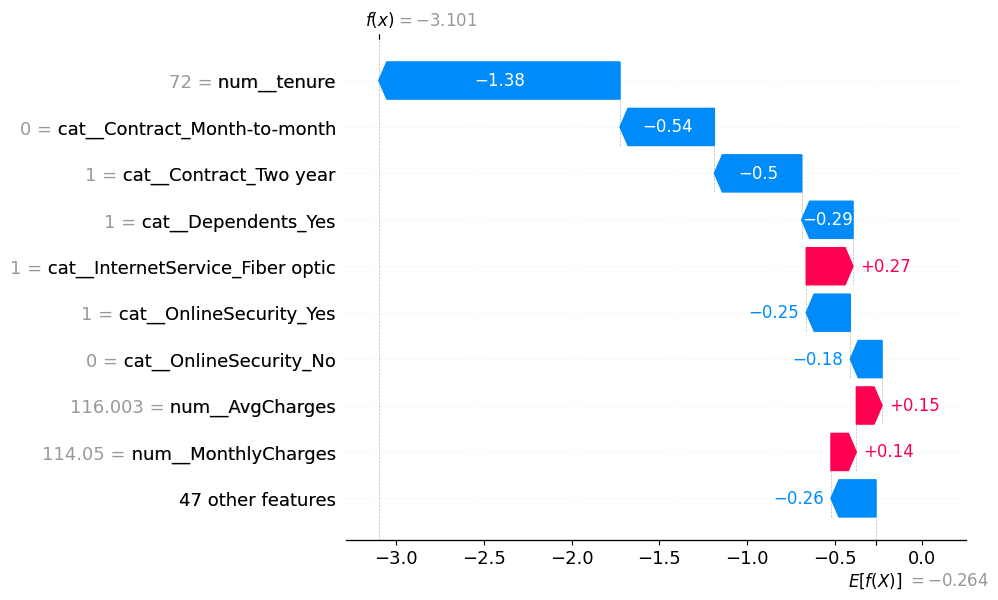

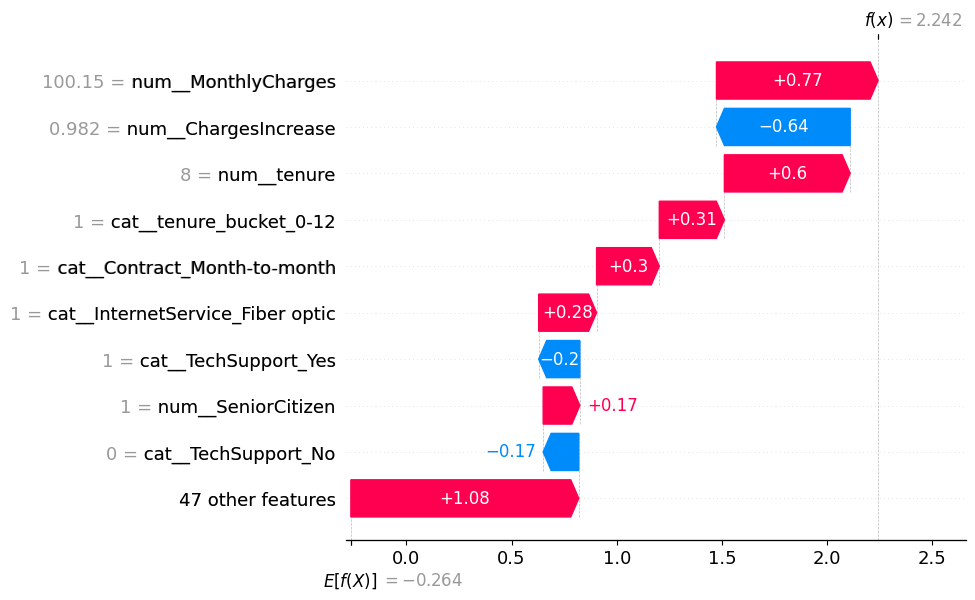

In [27]:
# Waterfall plot for a single customer (local explanation)
shap_values = explainer(pd.DataFrame(X_test_transformed, columns=feature_names))
shap.waterfall_plot(shap_values[0],)
shap.waterfall_plot(shap_values[1],)

We can analyse the most and least likely to churn clients through the prism of chap values:
- Most likely to churn: 1-month old client with large subsrciption fee, double their historical average charges, and fiber optic (unpopular service)
- Least likely to churn: Low charges, no month to month contract, no internet

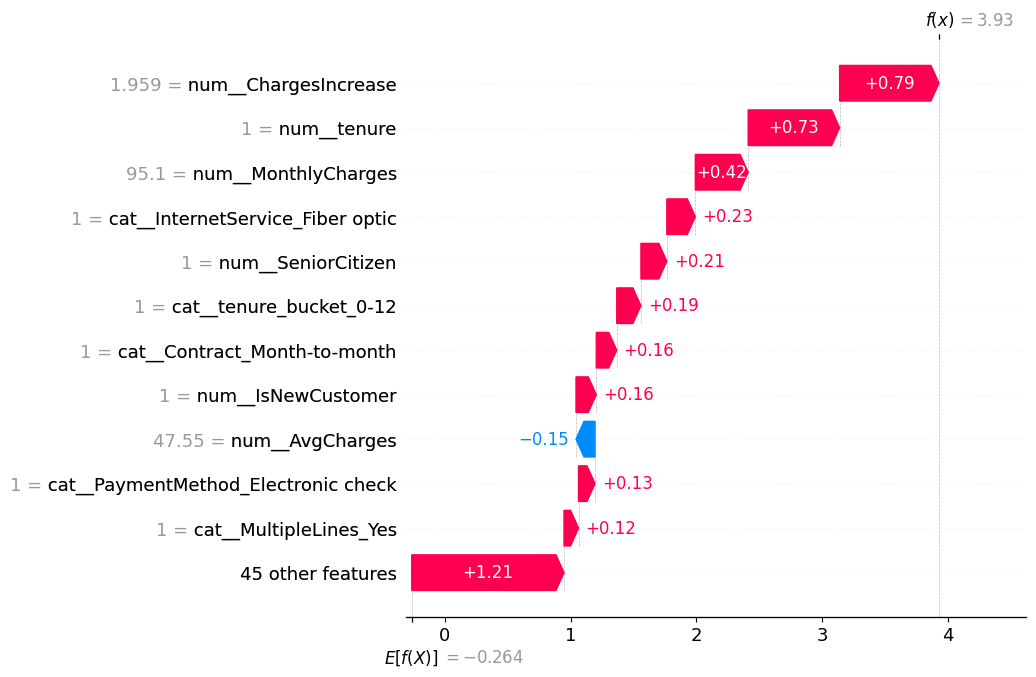

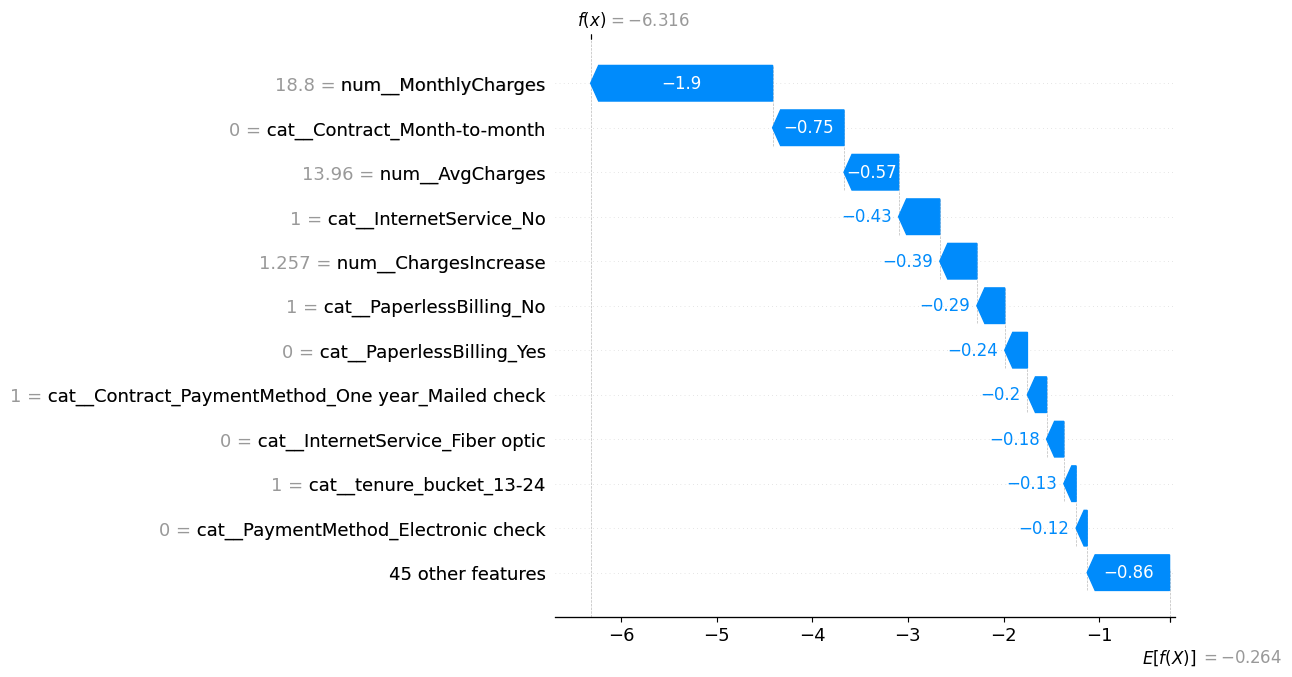

In [28]:
# profile most likely to churn
shap.waterfall_plot(shap_values[idx_max_churn_proba],max_display=12)
# profile less likely to churn
shap.waterfall_plot(shap_values[idx_min_churn_proba],max_display=12)

# Simulate alternative clients

We can play with the model and manually change the value of features in the test set to see the impact on the model prediction. 

First let's grab the probabilities and expected revenues before any modifications

In [29]:
# first, check the avg expected probability of churning
y_proba = pipes["CatBoost"].predict_proba(X_test)[:,1] 
ref_proba = y_proba.mean()
print("Expected Avg churn probability", round(ref_proba, 2))

Expected Avg churn probability 0.37


In [30]:
# Potential monthly revenue if no one had churned
print("Perfect revenues", round(X_test.MonthlyCharges.sum(), 0))

Perfect revenues 90301.0


In [31]:
# Expected revenue given the predicted churn probas
expected_revenue = X_test.MonthlyCharges.dot(1-y_proba)
expected_revenue
print("Expected revenues", round(expected_revenue, 0))

Expected revenues 52228.0


In [32]:
# real revenu for comparison. Our model is pessimistic 
print("Actual revenues", round(X_test.MonthlyCharges.dot(1-y_test), 0))

Actual revenues 63086.0


Our model is pessimistic 

## Changing charges

Let's simulate what our model think would happen if the MonthlyCharges of all clients had been higher/lower than what they actually were in the dataset

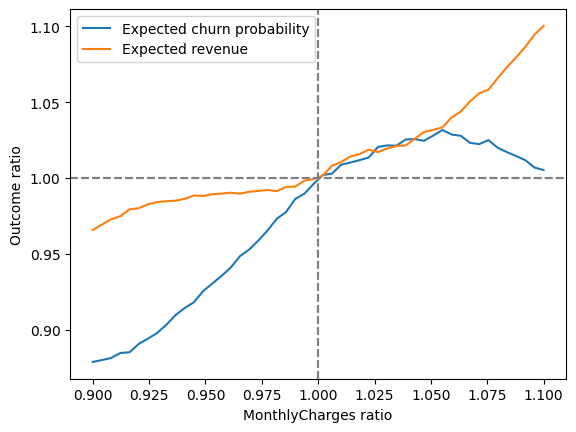

In [33]:
# check the predicted impact of perturbations (small increases or decreases) in monthly charges
y_proba_list = []
expected_revenue_list=[]
factor_list =  np.linspace(0.9, 1.1)
for factor in factor_list:
    X_test_ = X_test.copy()
    X_test_["MonthlyCharges"] *= factor
    X_test_["ChargesIncrease"] *= factor # need to increase this one too for realism
    y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
    y_proba_list += [(y_proba.mean()/ref_proba)]
    expected_revenue_list+= [X_test_.MonthlyCharges.dot(1-y_proba)/expected_revenue]

plt.plot(factor_list, y_proba_list, label="Expected churn probability")
plt.xlabel("MonthlyCharges ratio")
plt.axvline(x=1, color="grey", linestyle="--")
plt.axhline(y=1, color="grey", linestyle="--")

plt.plot(factor_list, expected_revenue_list, label="Expected revenue")
plt.ylabel("Outcome ratio")
plt.axvline(x=1, color="grey", linestyle="--")
plt.axhline(y=1, color="grey", linestyle="--")

plt.legend()

Our model is optimistic with regards to price changes and expects the retention to be more positively affected by a price decrease than negatively affected by a price increase.

So much so that it belives the expected revenues of the company are higher with a price increase despite the loss in clientele.

Client price sensitivity is knonw to be asymetric ([Kalyanaram, G. & Winer, R. S.](https://www.jstor.org/stable/184158)), but it is supposed to be in the other direction (clients more sensitive to price increase).
Hence this model probably isn't well calibrated to make price-elasticity predictions.
This isn't a surprise, the dataset provided isn't suited to a price-elasticity analysis. Indeed, such an analysis usually requires datasets with random price shocks, collected for that expressed purpose.

Regardless, we've showcased here how this family of models (trees, forests...) are well suited to represent such asymetrical behaviour, which is one of the reasons that they are a staple in the industry.


By comparison, the logistic regression, see below, even though formally non-linear, outputs almost-linear predictions for these ranges of values. Only by extending the scale of perturbation to around 100x the original price do we see a non linear profile. Not very realistic. 

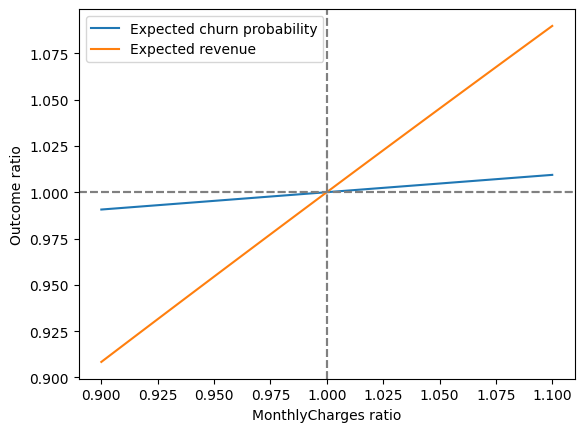

In [34]:
# check the predicted impact of perturbations (small increases or decreases) in monthly charges
y_proba_list = []
expected_revenue_list=[]
y_proba_lgr = pipes["Logistic Regression"].predict_proba(X_test)[:,1] 

ref_proba_lgr = y_proba_lgr.mean()
expected_revenue_lgr = X_test.MonthlyCharges.dot(1-y_proba_lgr)

factor_list =  np.linspace(0.9, 1.1)
for factor in factor_list:
    X_test_ = X_test.copy()
    X_test_["MonthlyCharges"] *= factor
    X_test_["ChargesIncrease"] *= factor
    y_proba = pipes["Logistic Regression"].predict_proba(X_test_)[:,1] 
    y_proba_list += [(y_proba.mean()/ref_proba_lgr)]
    expected_revenue_list+= [X_test_.MonthlyCharges.dot(1-y_proba)/expected_revenue_lgr]

plt.plot(factor_list, y_proba_list, label="Expected churn probability")
plt.xlabel("MonthlyCharges ratio")
plt.axvline(x=1, color="grey", linestyle="--")
plt.axhline(y=1, color="grey", linestyle="--")

plt.plot(factor_list, expected_revenue_list, label="Expected revenue")
plt.ylabel("Outcome ratio")
plt.axvline(x=1, color="grey", linestyle="--")
plt.axhline(y=1, color="grey", linestyle="--")

plt.legend()

## Changing other features

We can play around with other "what-if" scenarios

What if everyone had a monthly contract?

In [35]:
X_test_ = X_test.copy()
X_test_["Contract"] = "Month-to-month"
y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 1.12
Ratio in Expected revenues: 0.92


12% more churners, 8% revenue loss

What if everyone had a two year contract?

In [36]:
X_test_ = X_test.copy()
X_test_["Contract"] = "Two year"
y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 0.43
Ratio in Expected revenues: 1.39


57% less churners, 39% revenue gain

Big impact!

What if everyone was a long-tenured client?

In [37]:
X_test_ = X_test.copy()
X_test_["tenure_bucket"] = "49-72"
X_test_["tenure"] = 72
X_test_["IsNewCustomer"] = 0
y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 0.16
Ratio in Expected revenues: 1.6


84% less churners, 60% revenue gain

Enormous impact!

What if everyone was a short-tenured client?

In [38]:
X_test_ = X_test.copy()
X_test_["tenure_bucket"] = "0-12"
X_test_["tenure"] = 1
X_test_["IsNewCustomer"] = 1
X_test_["TotalCharges"] = X_test_.AvgCharges * X_test_.tenure

y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 1.27
Ratio in Expected revenues: 0.78


27% more churners, 22% revenue loss

What if everyone was male?

In [39]:
X_test_ = X_test.copy()
X_test_["gender"] = "Male"
y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 1.01
Ratio in Expected revenues: 0.99


No impact

What if everyone paid with Electronic check?

In [40]:
X_test_ = X_test.copy()
X_test_["PaymentMethod"] = "Electronic check"
y_proba = pipes["CatBoost"].predict_proba(X_test_)[:,1] 
print("Ratio in Churn Proba:", round(y_proba.mean() / ref_proba, 2))
print("Ratio in Expected revenues:", round(X_test_.MonthlyCharges.dot(1-y_proba) / expected_revenue, 2))

Ratio in Churn Proba: 1.06
Ratio in Expected revenues: 0.96


6% more churners, 4% revenue loss